In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ydata_profiling

In [55]:
df = pd.read_csv('Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [56]:
df.shape

(7043, 21)

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### Data Cleaning and transformation

In [58]:
df['PaperlessBilling'].unique()

array(['Yes', 'No'], dtype=object)

In [59]:
# # male - 1 female - 0
# # df['gender'] =  df['gender'].map({'Male':1,'Female':0}).astype('int64')


# cols =['Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingMovies', 'PaperlessBilling', 'Churn']
# # Yes - 1 No - 0
# df[cols] = df[cols].apply(lambda x:x.map({'Yes':1, 'No':0})).fillna(-1).astype('int64')
# df['Contract'] = df['Contract'].map({'One year':1, 'Month-to-month':0, 'Two year':2}).astype('int64')


# # df['MultipleLines'] = df['MultipleLines'].map({'Yes':1, 'No':0}).fillna(-1).astype('int64')
# # df['OnlineSecurity'] = df['OnlineSecurity'].map({'Yes':1, 'No':0}).fillna(-1).astype('int64')
# # df['OnlineBackup'] = df['OnlineBackup'].map({'Yes':1, 'No':0}).fillna(-1).astype('int64')
# # df['DeviceProtection'] = df['DeviceProtection'].map({'Yes':1, 'No':0}).fillna(-1).astype('int64')
# # 
# # df['TechSupport'] = df['TechSupport'].map({'Yes':1, 'No':0}).fillna(-1).astype('int64')
# # df['StreamingMovies'] = df['StreamingMovies'].map({'Yes':1, 'No':0}).fillna(-1).astype('int64')

# # df['PaperlessBilling'] = df['PaperlessBilling'].map({'Yes':1, 'No':0}).fillna(-1).astype('int64')
# # df['Churn'] = df['Churn'].map({'Yes':1, 'No':0}).astype('int64')


In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


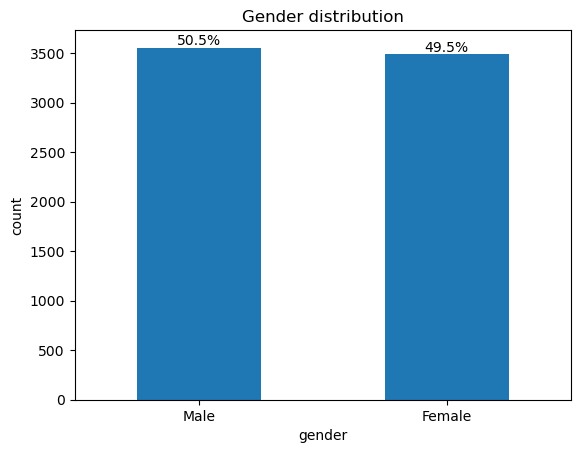

In [61]:
ax = df['gender'].value_counts().plot(kind='bar')

# axis labels
plt.xlabel('gender')
plt.ylabel('count')
plt.title('Gender distribution')
plt.xticks(rotation=0)

# total for percentage calculation
total = len(df)

# add % labels on top of bars
for p in ax.patches:
    count = int(p.get_height())
    percentage = f'{(count/total)*100:.1f}%'
    
    ax.annotate(percentage,
                (p.get_x() + p.get_width() / 2, count),
                ha='center', va='bottom')

plt.show()

In [62]:
df['Dependents'].groupby(df['Partner']).value_counts().reset_index(name='count')


,Partner,Dependents,count
0,No,No,3280
1,No,Yes,361
2,Yes,Yes,1749
3,Yes,No,1653


<Axes: xlabel='Dependents', ylabel='count'>

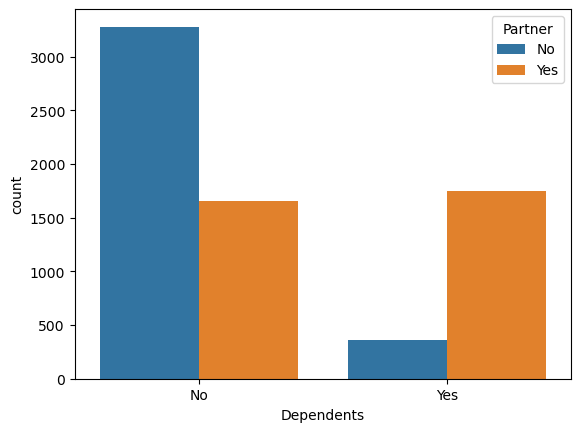

In [63]:
ax2 = (
    df['Dependents'].groupby(df['Partner']).value_counts().reset_index(name='count')
)

ax2['Dependents'] = ax2['Dependents'].astype(str)
ax2['Partner'] = ax2['Partner'].astype(str)

sns.barplot(data=ax2, x='Dependents', y='count', hue='Partner')


<Axes: xlabel='Dependents', ylabel='count'>

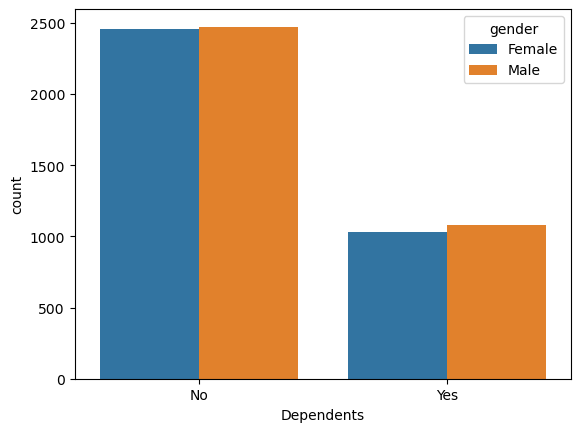

In [64]:
ax3 = (
    df['Dependents'].groupby(df['gender']).value_counts().reset_index(name='count')
)

ax3['Dependents'] = ax3['Dependents'].astype(str)
ax3['gender'] = ax3['gender'].astype(str)

sns.barplot(data=ax3, x='Dependents', y='count', hue='gender')

In [65]:
report= ydata_profiling.ProfileReport(df)
report.to_file('Telco_customer_report2.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 21/21 [00:00<00:00, 99.85it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

### Dropping unnecessary features

In [ ]:
#  High correlation between MultipleLines and PhoneService
df['MultipleLines'].groupby(df['PhoneService']).value_counts(normalize=True).reset_index(name='percentage')

# We can drop PhoenService.
# as we can see if MultipleLines is Yes or No then PhoneService is Yes only.

df.drop('PhoneService',axis=1,inplace=True)


In [72]:
pd.crosstab(df['Dependents'], df['Partner'],  normalize = 'columns')*100

# We can see that who have not partners. They are not dependent on anyone.
# We cannot drop any of these columns as they are not highly correlated.

Partner,No,Yes
Dependents,,
No,90.085141,48.589065
Yes,9.914859,51.410935


In [79]:
pd.crosstab(df['InternetService'], df['OnlineBackup'])
pd.crosstab(df['OnlineSecurity'], df['OnlineBackup'])

OnlineBackup,No,No internet service,Yes
OnlineSecurity,,,
No,2195,0,1303
No internet service,0,1526,0
Yes,893,0,1126


In [ ]:
df.groupby('InternetService')['MonthlyCharges'].mean().reset_index()
# df['InternetService'].value_counts(normalize=True).reset_index()

# From here we can see that Fiber optic has 44% of market share
# Fiber optic is too expensive than DSL.

,InternetService,MonthlyCharges
0,DSL,58.102169
1,Fiber optic,91.500129
2,No,21.079194


In [97]:
df.groupby('InternetService')['tenure'].mean().reset_index()

,InternetService,tenure
0,DSL,32.821561
1,Fiber optic,32.917959
2,No,30.547182


### EDA

#### EDA with gender 